In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [1]:
import kagglehub
path = kagglehub.dataset_download("camnugent/california-housing-prices")

Using Colab cache for faster access to the 'california-housing-prices' dataset.


In [4]:
data=fetch_california_housing(as_frame=True)
df=pd.concat([data.data,data.target.rename("HousePrice")],axis=1)
print(df.head())

   MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  HousePrice
0  8.3252      41.0  6.984127  ...     37.88    -122.23       4.526
1  8.3014      21.0  6.238137  ...     37.86    -122.22       3.585
2  7.2574      52.0  8.288136  ...     37.85    -122.24       3.521
3  5.6431      52.0  5.817352  ...     37.85    -122.25       3.413
4  3.8462      52.0  6.281853  ...     37.85    -122.25       3.422

[5 rows x 9 columns]


In [5]:
x=df.drop("HousePrice",axis=1)
y=df["HousePrice"]

In [10]:
scaler=StandardScaler()
x=scaler.fit_transform(x)
print("Feature completed successfully")


Feature completed successfully


In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("traininf data:",x_train.shape,y_train.shape)
print("testing data:",x_test.shape,y_test.shape)

traininf data: (16512, 8) (16512,)
testing data: (4128, 8) (4128,)


In [15]:
models={"Linear Regression":LinearRegression(),"Ridge Regression":Ridge(alpha=0.5),"Decision Tree":DecisionTreeRegressor(max_depth=5,random_state=42)}


In [16]:
results={}
for model_name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))
    r2=r2_score(y_test,y_pred)
    results[model_name]={"RMSE":rmse,"R2":r2}
    print(f"{model_name} - RMSE: {rmse}, R2: {r2}")



Linear Regression - RMSE: 0.7455813830127763, R2: 0.575787706032451
Ridge Regression - RMSE: 0.7455542909384612, R2: 0.5758185345441319
Decision Tree - RMSE: 0.7242338143386247, R2: 0.5997321244428706


In [17]:
best_model=min(results,key=lambda x:results[x]["RMSE"])
print("Best Model:",best_model)

Best Model: Decision Tree


/tmp/ipykernel_888/2101884118.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3,color='red')


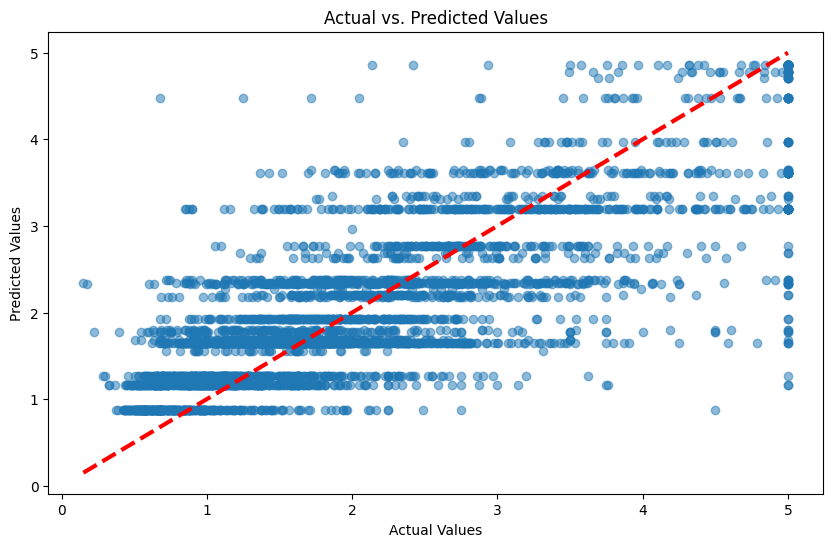

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3,color='red')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()